# Nathan Day - MATH 529L Worksheet 5



---



### Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import trapezoid
from scipy.special import jv
from scipy.optimize import brentq

import sympy as sp
from sympy import Eq
from sympy.physics.vector import ReferenceFrame
from sympy.printing.latex import latex

from IPython.display import display, Math, Markdown

LaTex setup

In [ ]:
# I think for this homework, since there are a lot of symbols that look better with LaTex,
# I will be using functions to output my answers in LaTex for visualizations sake

def show(expr):
    """Display a sympy expression as LaTeX."""
    display(Math(latex(expr)))

def show_text_md(s):
    display(Markdown(s))

def imshow_field(Z, x, y, title=""):
    plt.figure(figsize=(6,5))
    plt.imshow(Z.T, origin="lower",
               extent=[x.min(), x.max(), y.min(), y.max()],
               aspect="auto")
    plt.colorbar(label="u")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(title)
    plt.tight_layout()
    plt.show()

1.1

In [ ]:
show_text_md(r"---")
show_text_md(r"# 1) 2-D rectangular membrane")

# Symbols for derivation
x, y, t = sp.symbols('x y t', real=True)
L, H = sp.symbols('L H', positive=True, real=True)
c = sp.Symbol('c', positive=True, real=True)

X = sp.Function('X')(x)
Y = sp.Function('Y')(y)
T = sp.Function('T')(t)

# Separation of variables section with u(x,y,t) = X(x)Y(y)T(t)
show_text_md(r"## 1.1 Separation of Variables")

show_text_md(r"Assume $$u(x,y,t)=X(x)Y(y)T(t).$$")

# This is my derivation part
lam = sp.Symbol('lambda', real=True)
mu  = sp.Symbol('mu', real=True)

show_text_md(r"For the membrane PDE: $$u_{tt}=c^2(u_{xx}+u_{yy}).$$")
show(Eq(sp.diff(X*Y*T, t, 2), c**2*(sp.diff(X*Y*T, x, 2) + sp.diff(X*Y*T, y, 2))))

show_text_md(
r"""
Divide by $X Y T$:
$$\frac{T''}{c^2 T}=\frac{X''}{X}+\frac{Y''}{Y}.$$
Set $\frac{X''}{X}=-\lambda$ and $\frac{Y''}{Y}=-\mu$ with $\lambda,\mu>0$ (for Dirichlet),
so
$$X''+\lambda X=0,\quad Y''+\mu Y=0,\quad T''+c^2(\lambda+\mu)T=0.$$
"""
)

# Fixed ends for Dirichlet b.c.
show_text_md(
r"""
Fixed ends (Dirichlet):
$$u(0,y,t)=u(L,y,t)=u(x,0,t)=u(x,H,t)=0.$$
This leads us:
$$X(0)=X(L)=0,\quad Y(0)=Y(H)=0.$$
So:
$$X_m(x)=\sin\!\Big(\frac{m\pi x}{L}\Big),\;\lambda_m=\Big(\frac{m\pi}{L}\Big)^2,$$
$$Y_n(y)=\sin\!\Big(\frac{n\pi y}{H}\Big),\;\mu_n=\Big(\frac{n\pi}{H}\Big)^2.$$
"""
)

show_text_md(
r"""
Therefore the modal frequencies are
$$\omega_{mn}=c\sqrt{\lambda_m+\mu_n}
=\pi c\sqrt{\Big(\frac{m}{L}\Big)^2+\Big(\frac{n}{H}\Big)^2}.$$

General solution by separation of variables:
$$u(x,y,t)=\sum_{m=1}^\infty\sum_{n=1}^\infty
\Big(A_{mn}\cos(\omega_{mn}t)+B_{mn}\sin(\omega_{mn}t)\Big)
\sin\!\Big(\frac{m\pi x}{L}\Big)\sin\!\Big(\frac{n\pi y}{H}\Big).$$
"""
)

---

# 1) 2-D rectangular membrane

## 1.1 Separation of Variables

Assume $$u(x,y,t)=X(x)Y(y)T(t).$$

For the membrane PDE: $$u_{tt}=c^2(u_{xx}+u_{yy}).$$

<IPython.core.display.Math object>


Divide by $X Y T$:
$$\frac{T''}{c^2 T}=\frac{X''}{X}+\frac{Y''}{Y}.$$
Set $\frac{X''}{X}=-\lambda$ and $\frac{Y''}{Y}=-\mu$ with $\lambda,\mu>0$ (for Dirichlet),
so
$$X''+\lambda X=0,\quad Y''+\mu Y=0,\quad T''+c^2(\lambda+\mu)T=0.$$



Fixed ends (Dirichlet):
$$u(0,y,t)=u(L,y,t)=u(x,0,t)=u(x,H,t)=0.$$
This leads us:
$$X(0)=X(L)=0,\quad Y(0)=Y(H)=0.$$
So:
$$X_m(x)=\sin\!\Big(\frac{m\pi x}{L}\Big),\;\lambda_m=\Big(\frac{m\pi}{L}\Big)^2,$$
$$Y_n(y)=\sin\!\Big(\frac{n\pi y}{H}\Big),\;\mu_n=\Big(\frac{n\pi}{H}\Big)^2.$$



Therefore the modal frequencies are
$$\omega_{mn}=c\sqrt{\lambda_m+\mu_n}
=\pi c\sqrt{\Big(\frac{m}{L}\Big)^2+\Big(\frac{n}{H}\Big)^2}.$$

General solution by separation of variables:
$$u(x,y,t)=\sum_{m=1}^\infty\sum_{n=1}^\infty
\Big(A_{mn}\cos(\omega_{mn}t)+B_{mn}\sin(\omega_{mn}t)\Big)
\sin\!\Big(\frac{m\pi x}{L}\Big)\sin\!\Big(\frac{n\pi y}{H}\Big).$$


1.2

## 1.2 Eigenfrequency and plot

<IPython.core.display.Math object>

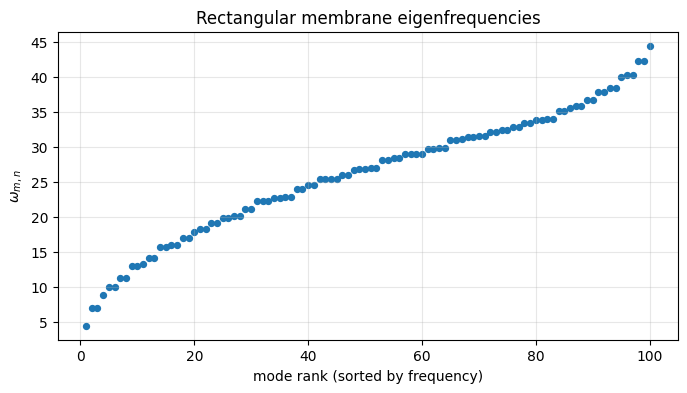

In [ ]:
# 1.2 Frequencies plot
show_text_md(r"## 1.2 Eigenfrequency and plot")

# The parameters
Lval = 1.0
Hval = 1.0
cval = 1.0
Mmax, Nmax = 10, 10

def omega_rect(m, n, L, H, c=1.0):
    return np.pi * c * np.sqrt((m/L)**2 + (n/H)**2)
display(Math(
    r"\omega_{m,n} = \pi c \sqrt{\left(\frac{m}{L}\right)^2 + \left(\frac{n}{H}\right)^2},"
    r"\qquad m,n = 1,2,3,\dots"
))

freqs = []
for m in range(1, Mmax+1):
    for n in range(1, Nmax+1):
        freqs.append((m, n, omega_rect(m, n, Lval, Hval, cval)))

freqs_sorted = sorted(freqs, key=lambda z: z[2])

k = np.arange(1, len(freqs_sorted) + 1)
wvals = np.array([z[2] for z in freqs_sorted])

# Plotting
plt.figure(figsize=(8,4))
plt.scatter(k, wvals, s=18)
plt.xlabel("mode rank (sorted by frequency)")
plt.ylabel(r"$\omega_{m,n}$")
plt.title("Rectangular membrane eigenfrequencies")
plt.grid(alpha=0.3)

1.3

## 1.3 Plot modes (1D and 2D)

<IPython.core.display.Math object>

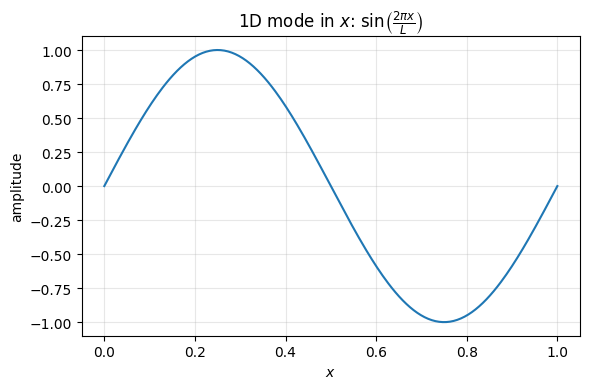

<IPython.core.display.Math object>

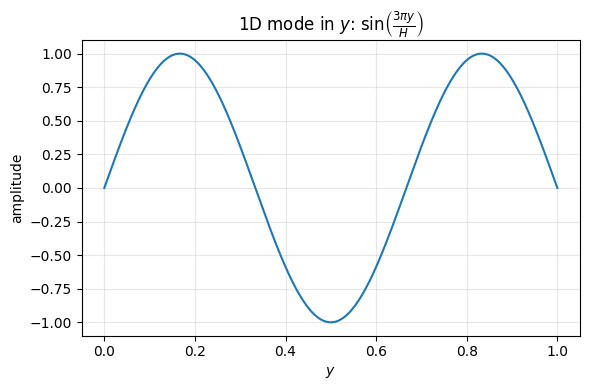

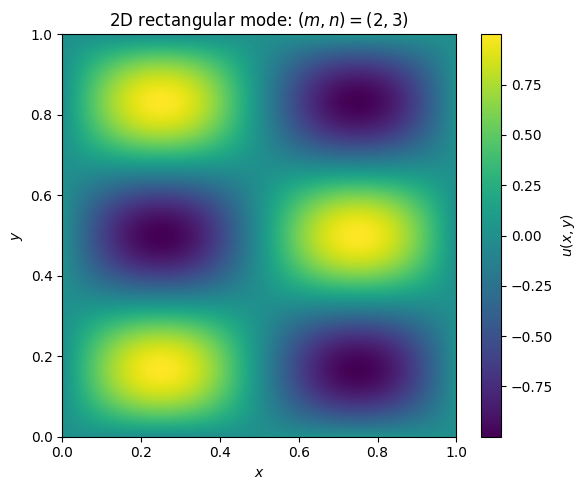

In [ ]:
# 1.3 Mode plots of 1D and 2D
show_text_md(r"## 1.3 Plot modes (1D and 2D)")

Nx, Ny = 250, 250
xgrid = np.linspace(0, Lval, Nx)
ygrid = np.linspace(0, Hval, Ny)
Xg, Yg = np.meshgrid(xgrid, ygrid, indexing="ij")

m_ex, n_ex = 2, 3

# 1D mode in x
display(Math(
    rf"X_{m_ex}(x) = \sin\!\left(\frac{{{m_ex}\pi x}}{{L}}\right)"
))

plt.figure(figsize=(6,4))
plt.plot(xgrid, np.sin(m_ex*np.pi*xgrid/Lval))
plt.xlabel(r"$x$")
plt.ylabel("amplitude")
plt.title(rf"1D mode in $x$: $\sin\!\left(\frac{{{m_ex}\pi x}}{{L}}\right)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 1D mode in y
display(Math(
    rf"Y_{n_ex}(y) = \sin\!\left(\frac{{{n_ex}\pi y}}{{H}}\right)"
))

plt.figure(figsize=(6,4))
plt.plot(ygrid, np.sin(n_ex*np.pi*ygrid/Hval))
plt.xlabel(r"$y$")
plt.ylabel("amplitude")
plt.title(rf"1D mode in $y$: $\sin\!\left(\frac{{{n_ex}\pi y}}{{H}}\right)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2D rectangular mode
Zmode = (
    np.sin(m_ex*np.pi*Xg/Lval) *
    np.sin(n_ex*np.pi*Yg/Hval)
)

plt.figure(figsize=(6,5))
plt.imshow(
    Zmode.T,
    origin="lower",
    extent=[0, Lval, 0, Hval],
    aspect="auto"
)
plt.colorbar(label=r"$u(x,y)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(rf"2D rectangular mode: $(m,n)=({m_ex},{n_ex})$")
plt.tight_layout()
plt.show()

1.4

In [ ]:
show_text_md(r"## 1.4 My discussion")

discussion_rect = r"""
**Rectangular modes: what do we observe physically?**

- Each mode (m,n) is a standing-wave pattern.
- Increasing m creates more oscillations in the x-direction. And, increasing n creates more oscillations in the y-direction.
- Higher spatial oscillation leads to higher frequency ω_{mn}. So high-(m,n) modes vibrate faster in time.
- The initial displacement f(x,y) determines how much of each mode is present.
  Modes with large coefficients A_{mn} dominate the observed motion.
"""
show_text_md(discussion_rect)

## 1.4 My discussion


**Rectangular modes: what do we observe physically?**

- Each mode (m,n) is a standing-wave pattern.
- Increasing m creates more oscillations in the x-direction. And, increasing n creates more oscillations in the y-direction.
- Higher spatial oscillation leads to higher frequency ω_{mn}. So high-(m,n) modes vibrate faster in time.
- The initial displacement f(x,y) determines how much of each mode is present.
  Modes with large coefficients A_{mn} dominate the observed motion.


1.5

In [ ]:
# 1.5 Deriving the coeff formula
show_text_md(r"## 1.5 Deriving the coefficient formulas")

show_text_md(
r"""
Using orthogonality:
$$\int_0^L \sin\!\Big(\frac{m\pi x}{L}\Big)\sin\!\Big(\frac{p\pi x}{L}\Big)\,dx
=\frac{L}{2}\delta_{mp},$$
and similarly in y. Matching $u(x,y,0)=f(x,y)$ gives
$$A_{mn}=\frac{4}{LH}\int_0^L\int_0^H f(x,y)\sin\!\Big(\frac{m\pi x}{L}\Big)\sin\!\Big(\frac{n\pi y}{H}\Big)\,dy\,dx.$$
Matching $u_t(x,y,0)=g(x,y)$ gives
$$B_{mn}=\frac{4}{LH\,\omega_{mn}}\int_0^L\int_0^H g(x,y)\sin\!\Big(\frac{m\pi x}{L}\Big)\sin\!\Big(\frac{n\pi y}{H}\Big)\,dy\,dx.$$
"""
)

## 1.5 Deriving the coefficient formulas


Using orthogonality:
$$\int_0^L \sin\!\Big(\frac{m\pi x}{L}\Big)\sin\!\Big(\frac{p\pi x}{L}\Big)\,dx
=\frac{L}{2}\delta_{mp},$$
and similarly in y. Matching $u(x,y,0)=f(x,y)$ gives
$$A_{mn}=\frac{4}{LH}\int_0^L\int_0^H f(x,y)\sin\!\Big(\frac{m\pi x}{L}\Big)\sin\!\Big(\frac{n\pi y}{H}\Big)\,dy\,dx.$$
Matching $u_t(x,y,0)=g(x,y)$ gives
$$B_{mn}=\frac{4}{LH\,\omega_{mn}}\int_0^L\int_0^H g(x,y)\sin\!\Big(\frac{m\pi x}{L}\Big)\sin\!\Big(\frac{n\pi y}{H}\Big)\,dy\,dx.$$


1.6

## 1.6 Plot solution with Gaussian pulse initial displacement (g=0)

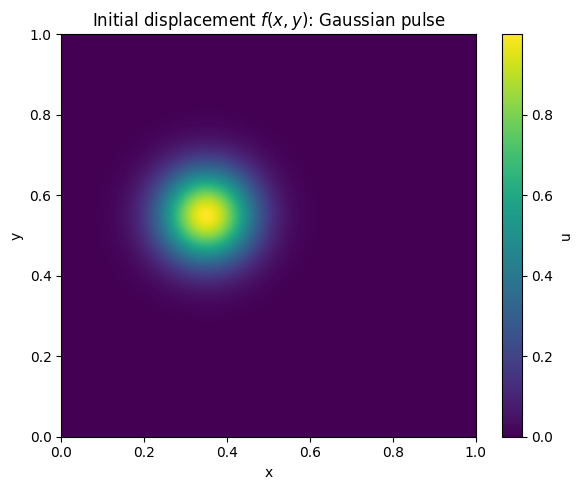

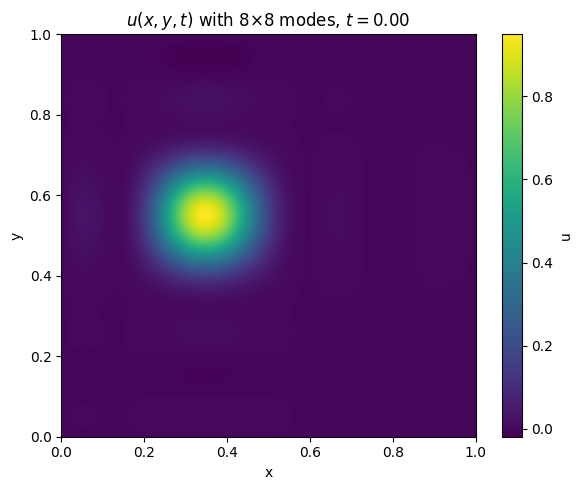

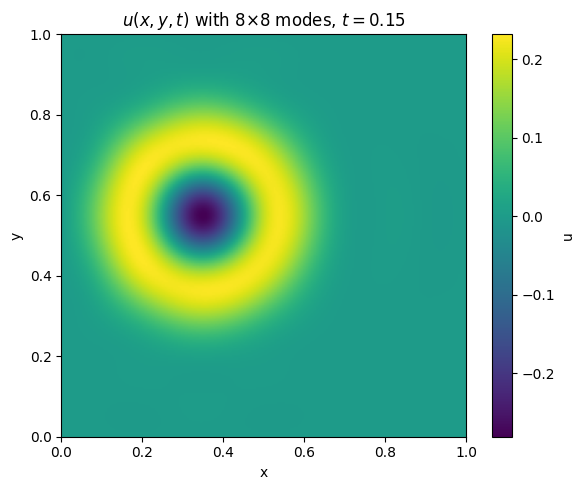

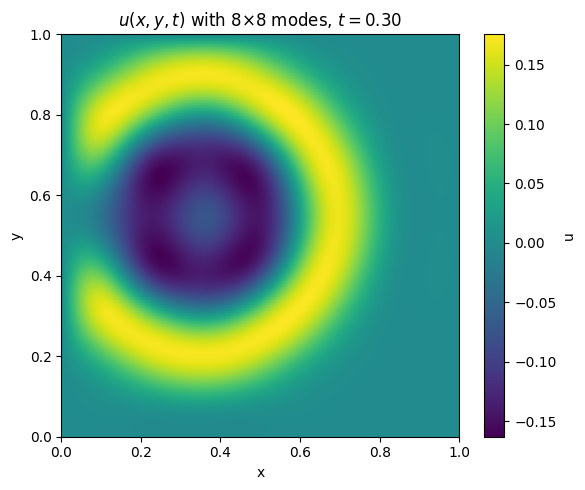

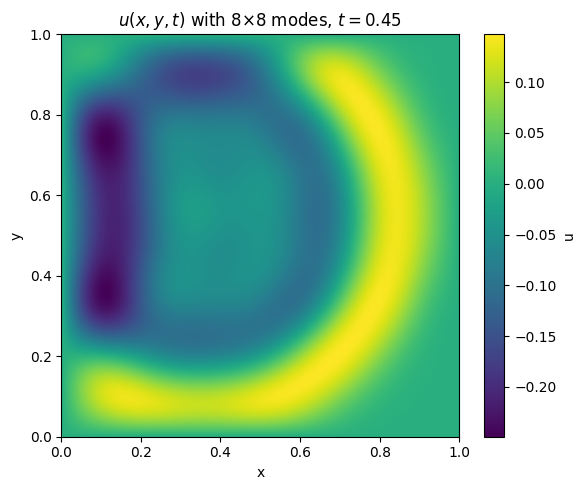

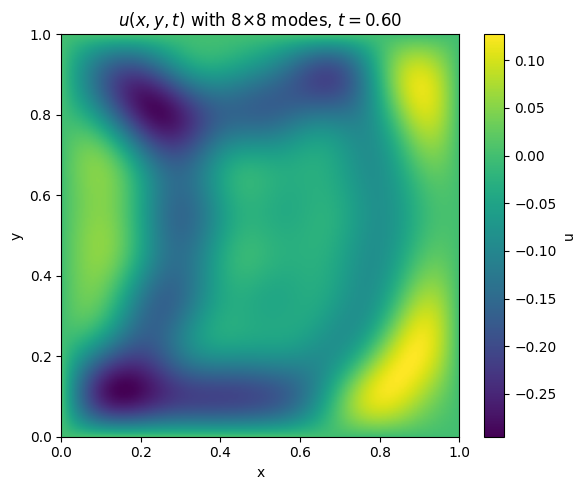

In [ ]:
# 1.6 Reconstruct solution from finitely many modes
show_text_md(r"## 1.6 Plot solution with Gaussian pulse initial displacement (g=0)")

def gaussian_pulse(X, Y, x0, y0, sigma):
    return np.exp(-((X-x0)**2 + (Y-y0)**2)/(2*sigma**2))

x0, y0, sigma = 0.35*Lval, 0.55*Hval, 0.08
f_xy = gaussian_pulse(Xg, Yg, x0, y0, sigma)
g_xy = np.zeros_like(f_xy)  # g=0

# Let's compute the Fourier coefficients
def compute_coeffs_rect(fxy, gxy, Mmax, Nmax):
    A = np.zeros((Mmax, Nmax))
    B = np.zeros((Mmax, Nmax))

    for m in range(1, Mmax+1):
        sinx = np.sin(m*np.pi*Xg/Lval)
        for n in range(1, Nmax+1):
            siny = np.sin(n*np.pi*Yg/Hval)
            basis = sinx * siny

            # A_mn = (4/LH) ∫∫ f * basis
            int_y  = trapezoid(fxy * basis, ygrid, axis=1)
            int_xy = trapezoid(int_y, xgrid, axis=0)
            A[m-1, n-1] = (4.0/(Lval*Hval)) * int_xy

            # B_mn = (4/(LH*omega_mn)) ∫∫ g * basis
            w = omega_rect(m, n, Lval, Hval, cval)
            int_y_g  = trapezoid(gxy * basis, ygrid, axis=1)
            int_xy_g = trapezoid(int_y_g, xgrid, axis=0)
            B[m-1, n-1] = (4.0/(Lval*Hval*w)) * int_xy_g if w != 0 else 0.0

    return A, B

A_rect, B_rect = compute_coeffs_rect(f_xy, g_xy, Mmax=8, Nmax=8)

def solution_rect(tval, A, B):
    U = np.zeros_like(Xg)
    Mmax, Nmax = A.shape

    for m in range(1, Mmax+1):
        sinx = np.sin(m*np.pi*Xg/Lval)
        for n in range(1, Nmax+1):
            siny = np.sin(n*np.pi*Yg/Hval)
            spatial = sinx * siny
            w = omega_rect(m, n, Lval, Hval, cval)

            U += (A[m-1, n-1]*np.cos(w*tval) + B[m-1, n-1]*np.sin(w*tval)) * spatial

    return U

# Plotting tool for convenience of the initial displacement
def imshow_field(Z, x, y, title=""):
    plt.figure(figsize=(6,5))
    plt.imshow(Z.T, origin="lower",
               extent=[x.min(), x.max(), y.min(), y.max()],
               aspect="auto")
    plt.colorbar(label="u")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot initial displacement
imshow_field(f_xy, xgrid, ygrid, title="Initial displacement $f(x,y)$: Gaussian pulse")

# Plot solution snapshots
for tval in [0.0, 0.15, 0.30, 0.45, 0.60]:
    U = solution_rect(tval, A_rect, B_rect)
    imshow_field(U, xgrid, ygrid, title=rf"$u(x,y,t)$ with 8×8 modes, $t={tval:.2f}$")

2.1

In [ ]:
# 2.1 General solution
show_text_md(r"## 2.1 General separated solution (fixed edge)")

show_text_md(
r"""
A real-valued modal term is:
$$u_{mk}(r,\theta,t)=\left(C_{mk}\cos(\omega_{mk}t)+D_{mk}\sin(\omega_{mk}t)\right)
J_m\left(\frac{j_{m,k}}{a}r\right)\cos(m\theta),$$
and similarly with $\sin(m\theta)$.
The full solution is a double sum over $m=0,1,2,\dots$ and $k=1,2,3,\dots$.
"""
)

## 2.1 General separated solution (fixed edge)


A real-valued modal term is:
$$u_{mk}(r,\theta,t)=\left(C_{mk}\cos(\omega_{mk}t)+D_{mk}\sin(\omega_{mk}t)\right)
J_m\left(\frac{j_{m,k}}{a}r\right)\cos(m\theta),$$
and similarly with $\sin(m\theta)$.
The full solution is a double sum over $m=0,1,2,\dots$ and $k=1,2,3,\dots$.


2.2

## 2.2 Frequencies + plot (root-finding for Bessel zeros)

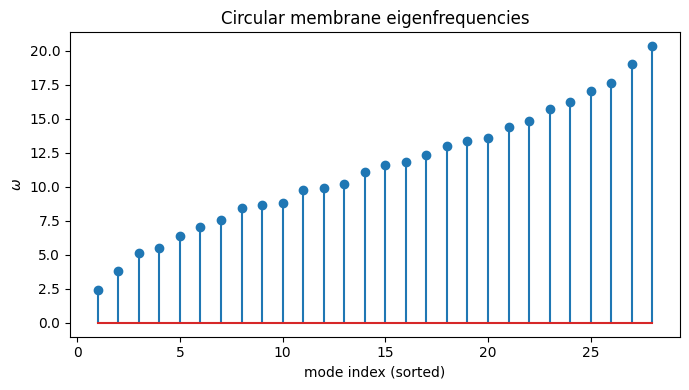

In [ ]:
# 2.2 Frequencies plot: need root finding algorithm
show_text_md(r"## 2.2 Frequencies + plot (root-finding for Bessel zeros)")

def bessel_zero_brentq(m, k, scan_max=None, scan_N=30000, rtol=1e-12):
    if scan_max is None:
        scan_max = (k + m/2 + 2.0) * np.pi

    xs = np.linspace(1e-6, scan_max, scan_N)
    vals = jv(m, xs)

    idxs = np.where(np.sign(vals[:-1]) * np.sign(vals[1:]) < 0)[0]
    if len(idxs) < k:
        raise RuntimeError(f"Not enough roots found for m={m}, k={k}. Increase scan_max/scan_N.")

    i = idxs[k-1]
    a, b = xs[i], xs[i+1]
    return brentq(lambda z: jv(m, z), a, b, xtol=1e-12, rtol=rtol, maxiter=200)

# Parameters
a_radius = 1.0
m_max = 6
k_max = 4

zeros = {m: [] for m in range(m_max+1)}
circ_freqs = []

for m in range(m_max+1):
    for k in range(1, k_max+1):
        jmk = bessel_zero_brentq(m, k)
        zeros[m].append(jmk)
        omega_mk = (cval * jmk) / a_radius
        circ_freqs.append((m, k, omega_mk))

circ_sorted = sorted(circ_freqs, key=lambda z: z[2])

plt.figure(figsize=(7,4))
plt.stem(range(1, len(circ_sorted)+1), [z[2] for z in circ_sorted])
plt.xlabel("mode index (sorted)")
plt.ylabel(r"$\omega$")
plt.title("Circular membrane eigenfrequencies")
plt.tight_layout()
plt.show()

2.3

## 2.3 2D plot of circular modes

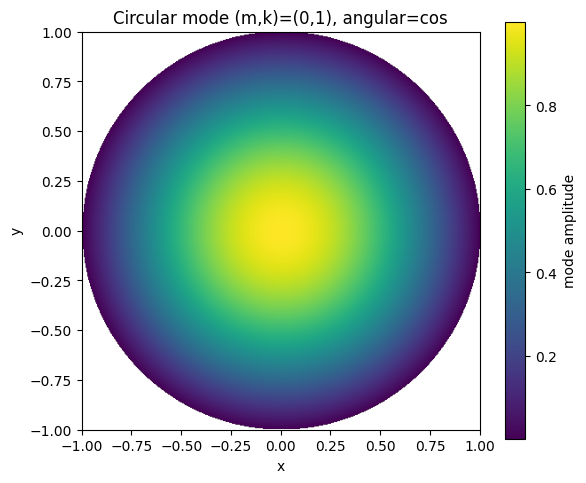

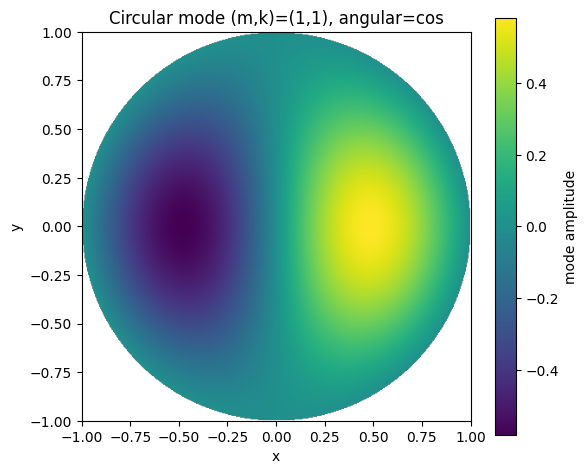

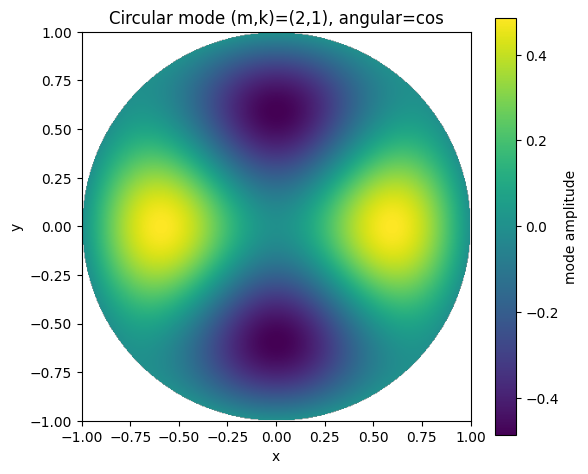

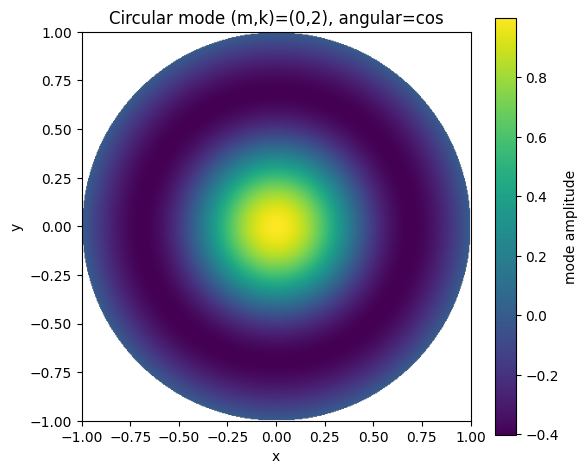

In [ ]:
# 2.3 Plot 2D modes on the disk

show_text_md(r"## 2.3 2D plot of circular modes")

N = 450
xx = np.linspace(-a_radius, a_radius, N)
yy = np.linspace(-a_radius, a_radius, N)
XX, YY = np.meshgrid(xx, yy, indexing="xy")
RR = np.sqrt(XX**2 + YY**2)
TH = np.arctan2(YY, XX)

def circ_mode(m, k, angular="cos"):
    jmk = zeros[m][k-1]
    Z = np.zeros_like(RR)
    mask = RR <= a_radius
    r = RR[mask]
    theta = TH[mask]

    radial = jv(m, jmk * r / a_radius)
    ang = np.cos(m*theta) if angular == "cos" else np.sin(m*theta)

    Z[mask] = radial * ang
    Z[~mask] = np.nan
    return Z

# Show a few modes
modes_to_show = [(0,1,"cos"), (1,1,"cos"), (2,1,"cos"), (0,2,"cos")]

for (m_s, k_s, ang) in modes_to_show:
    Z = circ_mode(m_s, k_s, angular=ang)
    plt.figure(figsize=(6,5))
    plt.imshow(Z, origin="lower", extent=[-a_radius,a_radius,-a_radius,a_radius])
    plt.colorbar(label="mode amplitude")
    plt.gca().set_aspect("equal", "box")
    plt.title(f"Circular mode (m,k)=({m_s},{k_s}), angular={ang}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.tight_layout()
    plt.show()

3.1 - 3.3

In [ ]:
show_text_md(r"---")
show_text_md(r"# 3) General questions")

# Q1 Neumann BC physical expectation
ans_neumann = r"""
## 3.1 Neumann boundary conditions: what happens physically?

Mathematical definition (Neumann): specify normal derivative at the boundary.
- Rectangle: $\frac{\partial u}{\partial n}=0$ on each edge, e.g.
  $u_x(0,y,t)=u_x(L,y,t)=0$ and $u_y(x,0,t)=u_y(x,H,t)=0$.
- Circle: $u_r(a,\theta,t)=0$.

Physical expectation:
Neumann means the boundary has zero slope in the outward normal direction (no “tilt” at the boundary).
This corresponds to a free edge (not clamped to zero displacement).
So you would expect the membrane’s edge to be able to move up/down, changing the allowed mode shapes and
usually reducing the fundamental frequency compared to fixed-edge (Dirichlet) conditions.
"""
show_text_md(ans_neumann)

# Q2 differences rectangular vs circular
ans_diff = r"""
## 3.2 Physical differences in mode shapes: rectangular vs circular

- Rectangular fixed-edge modes factor into sine waves:
  $\sin(m\pi x/L)\sin(n\pi y/H)$, giving nodal lines that are straight and aligned with the axes.
- Circular fixed-edge modes involve Bessel functions in radius and sinusoidal dependence in angle:
  $J_m(j_{m,k} r/a)\cos(m\theta)$ or $\sin(m\theta)$, giving nodal curves that are circles (radial nodes) and spokes (angular nodes).

So the geometry of the boundary strongly dictates the geometry of the nodal sets.
"""
show_text_md(ans_diff)

# Q3 symmetry along an axis in circular separation
ans_sym = r"""
## 3.3 If the circular membrane is symmetric along an axis, what happens?

If the solution is symmetric about (say) the $x$-axis, then
$$u(r,\theta,t)=u(r,-\theta,t).$$

In the separation solution, the angular basis is $\cos(m\theta)$ and $\sin(m\theta)$.
- $\cos(m\theta)$ is even in $\theta$ (keeps symmetry),
- $\sin(m\theta)$ is odd in $\theta$ (breaks symmetry).

Therefore symmetry forces all $\sin(m\theta)$ terms to have zero coefficient, leaving only cosine angular modes.
If the membrane is fully radially symmetric, then only $m=0$ modes remain.
"""
show_text_md(ans_sym)

---

# 3) General questions


## 3.1 Neumann boundary conditions: what happens physically?

Mathematical definition (Neumann): specify normal derivative at the boundary.
- Rectangle: $\frac{\partial u}{\partial n}=0$ on each edge, e.g.
  $u_x(0,y,t)=u_x(L,y,t)=0$ and $u_y(x,0,t)=u_y(x,H,t)=0$.
- Circle: $u_r(a,\theta,t)=0$.

Physical expectation:
Neumann means the boundary has zero slope in the outward normal direction (no “tilt” at the boundary).
This corresponds to a free edge (not clamped to zero displacement).  
So you would expect the membrane’s edge to be able to move up/down, changing the allowed mode shapes and
usually reducing the fundamental frequency compared to fixed-edge (Dirichlet) conditions.



## 3.2 Physical differences in mode shapes: rectangular vs circular

- Rectangular fixed-edge modes factor into sine waves:
  $\sin(m\pi x/L)\sin(n\pi y/H)$, giving nodal lines that are straight and aligned with the axes.
- Circular fixed-edge modes involve Bessel functions in radius and sinusoidal dependence in angle:
  $J_m(j_{m,k} r/a)\cos(m\theta)$ or $\sin(m\theta)$, giving nodal curves that are circles (radial nodes) and spokes (angular nodes).

So the geometry of the boundary strongly dictates the geometry of the nodal sets.



## 3.3 If the circular membrane is symmetric along an axis, what happens?

If the solution is symmetric about (say) the $x$-axis, then
$$u(r,\theta,t)=u(r,-\theta,t).$$

In the separation solution, the angular basis is $\cos(m\theta)$ and $\sin(m\theta)$.
- $\cos(m\theta)$ is even in $\theta$ (keeps symmetry),
- $\sin(m\theta)$ is odd in $\theta$ (breaks symmetry).

Therefore symmetry forces all $\sin(m\theta)$ terms to have zero coefficient, leaving only cosine angular modes.
If the membrane is fully radially symmetric, then only $m=0$ modes remain.
